<a href="https://colab.research.google.com/github/Revathi5419/INFOSYS-_INTERNSHIP-OIL_SPILL_DETECTION-/blob/Revathi/Copy_of_Welcome_to.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile

# The path to your uploaded zip file in Google Drive
zip_file_path = '/content/drive/MyDrive/Oil_Spill_Dataset.zip'
# The directory where you want to extract the files
extract_path = './'

# Check if the file exists and then unzip it
if os.path.exists(zip_file_path):
    print(f"Unzipping {zip_file_path}...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Unzipping complete. The files are now in the current directory.")
    except zipfile.BadZipFile:
        print(f"Error: {zip_file_path} is not a valid zip file.")
    except FileNotFoundError:
        print(f"Error: Extraction path {extract_path} not found.")
else:
    print(f"File not found: {zip_file_path}. Please ensure the file is in your Google Drive and that Google Drive is mounted.")

Unzipping /content/drive/MyDrive/Oil_Spill_Dataset.zip...
Unzipping complete. The files are now in the current directory.


In [ ]:
# The ! prefix allows you to run shell commands in Colab
!unzip Oil_Spill_Dataset.zip

unzip:  cannot find or open Oil_Spill_Dataset.zip, Oil_Spill_Dataset.zip.zip or Oil_Spill_Dataset.zip.ZIP.


In [ ]:
# Use this to see the exact file structure
!ls -R

.:
drive  label_colors.txt  sample_data  test  train  val

./drive:
MyDrive

./drive/MyDrive:
'5th .pdf'
 AI_SpillGuard_Oil_Spill_Detection.pdf
'anitha axis.pdf'
'Chemistry '
'Colab Notebooks'
'DSC_5559-1 (1).JPG'
 DSC_5559-1.JPG
'global logic.pdf'
 IMG20241026153150.jpg
'IMG20241030203942 (1).heic'
 IMG20241030203942.heic
 mani.wav
 mca.pdf
 M.SaiRevathi.pdf
'Mudapaka SaiRevathi '
'Mudapaka SaiRevathi  (1)'
'Mudapaka Sai Revathi (1).pdf'
'Mudapaka Sai Revathi (2).pdf'
'Mudapaka Sai Revathi.docx'
 Mudapaka_Sai_Revathi.docx
'Mudapaka Sai Revathi.pdf'
 Oil_Spill_Dataset.zip
 ramayya.pdf
 Screenshot_2024-02-15-10-09-19-44_c37d74246d9c81aa0bb824b57eaf7062.jpg
'Untitled document.gdoc'
'Untitled spreadsheet.gsheet'
'vaccination certificate.pdf'

'./drive/MyDrive/Chemistry ':
'Document from ~Revathi'   IMG20240729113952.jpg   IMG20240729115451.jpg
 IMG20240727112223.jpg	   IMG20240729114220.jpg   M.S.Revathi

'./drive/MyDrive/Colab Notebooks':
'Copy of Welcome to '   second

./sample_data:
an

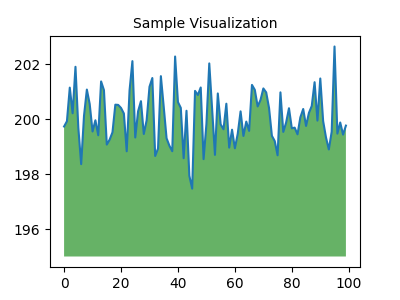

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

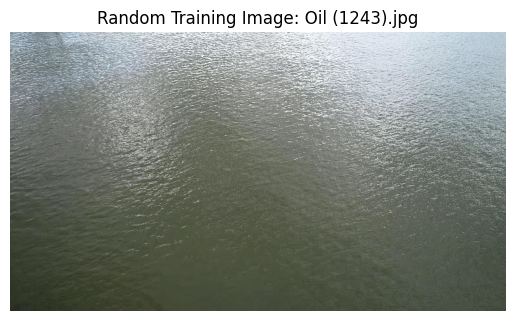

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

def display_random_image(folder_path, title="Random Image"):
    """
    Displays a random image from a specified folder.

    Args:
        folder_path (str): The path to the directory containing the images.
        title (str): The title for the displayed image window.
    """
    # Get a list of all files in the directory
    try:
        all_files = os.listdir(folder_path)
    except FileNotFoundError:
        print(f"Error: The directory '{folder_path}' was not found.")
        return

    # Filter for common image file extensions
    image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    # Check if any images were found
    if not image_files:
        print(f"No image files found in '{folder_path}'.")
        return

    # Select a random image from the list
    random_image_name = random.choice(image_files)
    image_path = os.path.join(folder_path, random_image_name)

    # Read the image using OpenCV
    image = cv2.imread(image_path)

    # Check if the image was read successfully
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return

    # Convert the image from BGR to RGB for correct display with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(image_rgb)
    plt.title(f"{title}: {random_image_name}")
    plt.axis('off')  # Hide the axis
    plt.show()

# Example usage with your correct paths
# Choose one of the image directories from your file structure
train_images_folder = './train/images'
test_images_folder = './test/images'

# Now you can call the function with the correct folder path
display_random_image(train_images_folder, "Random Training Image")

In [ ]:
import numpy as np
import cv2
import os # Import os to join paths

def preprocess_image(image_path, target_size=(224, 224)):
    """
    Loads, resizes, and normalizes an image.

    Args:
        image_path (str): The path to the image file.
        target_size (tuple): The desired dimensions (width, height).

    Returns:
        np.ndarray: The preprocessed image array.
    """
    # Read the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}") # Added error message
        return None

    # Resize the image
    resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

    # Normalize the pixel values to [0, 1]
    normalized_img = resized_img.astype(np.float32) / 255.0

    return normalized_img

# Example usage with a sample image
# Define the path to a sample image from your dataset
first_image_path = './train/images/Oil (1000).jpg' # Replace with an actual image path

preprocessed_img = preprocess_image(first_image_path)
if preprocessed_img is not None:
    print(f"Original image shape: {cv2.imread(first_image_path).shape}")
    print(f"Preprocessed image shape: {preprocessed_img.shape}")
    print(f"Example normalized pixel value: {preprocessed_img[0, 0, :]}")

Original image shape: (1080, 1920, 3)
Preprocessed image shape: (224, 224, 3)
Example normalized pixel value: [0.42352942 0.5372549  0.47843137]


In [ ]:
import numpy as np
import cv2
import os

def normalize_image(image_path):
    """
    Loads an image, converts it to a NumPy array, and normalizes its pixel values.

    Args:
        image_path (str): The path to the image file.

    Returns:
        np.ndarray: The normalized image array with pixel values in [0, 1].
    """
    # Load the image using OpenCV
    image = cv2.imread(image_path)

    # Check if the image was loaded correctly
    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Convert the image from BGR (OpenCV default) to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Normalize the pixel values by dividing by 255.0
    normalized_image = image / 255.0

    return normalized_image

# --- Updated section to find a valid image path ---
# Define the path to the directory containing the images.
# This assumes your directory structure is `Oil_Spill_Dataset/train/spill/`
# You can change this to match your actual file structure.
image_folder = './train/images'

# Check if the folder exists
if not os.path.isdir(image_folder):
    print(f"Error: The folder '{image_folder}' does not exist.")
    # You might want to provide instructions to the user here.
    exit()

# Get a list of all files in the directory
image_files = os.listdir(image_folder)

# Filter for common image file extensions
image_files = [f for f in image_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

# Check if any image files were found
if not image_files:
    print(f"Error: No image files found in '{image_folder}'.")
    exit()

# Get the full path of the first image in the list
first_image_path = os.path.join(image_folder, image_files[0])

print(f"Using image file: {first_image_path}")

# Example usage with the dynamically found image path
normalized_img = normalize_image(first_image_path)

if normalized_img is not None:
    print(f"Original image shape: {cv2.imread(first_image_path).shape}")
    print(f"Normalized image shape: {normalized_img.shape}")
    print(f"Example normalized pixel value: {normalized_img[0, 0, :]}")

Using image file: ./train/images/Oil (1180).jpg
Original image shape: (432, 768, 3)
Normalized image shape: (432, 768, 3)
Example normalized pixel value: [0.17647059 0.21960784 0.16470588]


In [ ]:
!pip install albumentations

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


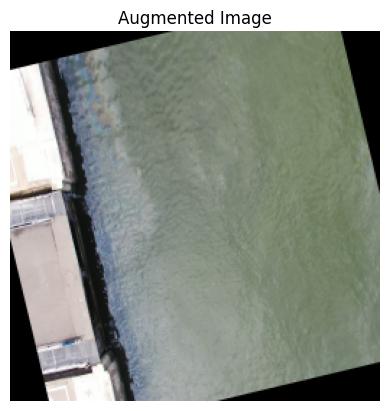

In [ ]:
import albumentations as A
import cv2
import matplotlib.pyplot as plt
import os # Import os to construct paths

def augment_image(image_path):
    """
    Applies a series of augmentations to an image.

    Args:
        image_path (str): The path to the image file.

    Returns:
        np.ndarray: The augmented image.
    """
    # Load the image
    image = cv2.imread(image_path)

    # Add a check to see if the image was loaded
    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Define the augmentation pipeline
    transform = A.Compose([
        A.Resize(256, 256),  # Resize to a consistent size
        A.HorizontalFlip(p=0.5), # Flip horizontally with a 50% probability
        A.RandomBrightnessContrast(p=0.2), # Randomly change brightness and contrast
        A.Rotate(limit=30, p=0.8), # Rotate the image up to 30 degrees
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5), # Apply random affine transformations
        A.GaussNoise(p=0.2), # Add Gaussian noise
    ])

    # Apply the transformations
    augmented_image = transform(image=image)['image']

    return augmented_image

# Example usage (replace with a real image path)
example_image_path = './train/images/Oil (1000).jpg' # Replace with an actual image path
augmented_img = augment_image(example_image_path)

# You can also apply augmentation and normalization together
# combined_transform = A.Compose([
#     A.HorizontalFlip(p=0.5),
#     A.RandomBrightnessContrast(p=0.2),
#     A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # Normalize with specific mean/std
# ])

# Optional: Display the augmented image
if augmented_img is not None:
    plt.imshow(augmented_img)
    plt.title("Augmented Image")
    plt.axis('off')
    plt.show()

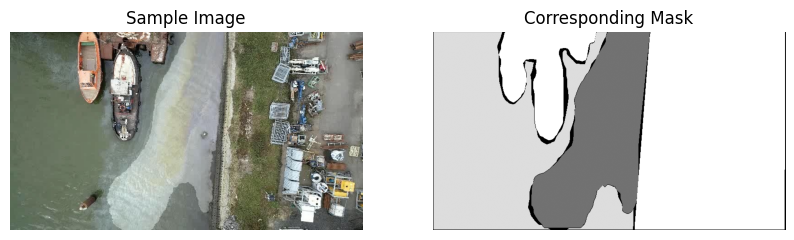

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def display_image_and_mask(image_dir, mask_dir, image_id):
    """
    Loads and displays a sample image and its corresponding mask.

    Args:
        image_dir (str): The directory containing the images.
        mask_dir (str): The directory containing the masks.
        image_id (str): The filename of the image (e.g., 'Oil (1).jpg').
    """
    # Construct the full file paths
    image_path = os.path.join(image_dir, image_id)
    mask_path = os.path.join(mask_dir, image_id.replace('.jpg', '.png'))

    # Load the image in RGB
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Load the mask in grayscale
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"Error: Could not load mask from {mask_path}")
        return

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Display the image
    axes[0].imshow(image)
    axes[0].set_title('Sample Image')
    axes[0].axis('off')

    # Display the mask
    # You can apply a colormap to the mask for better visualization
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Corresponding Mask')
    axes[1].axis('off')

    plt.show()

# --- Example Usage ---
# Define the directories for images and masks
IMAGE_DIR = './train/images'
MASK_DIR = './train/masks'

# Pick a single image file from the directory
# This assumes there's at least one image in the folder
try:
    image_files = os.listdir(IMAGE_DIR)
    # Get the first image file that is a .jpg
    image_file = next(f for f in image_files if f.endswith('.jpg'))
except (FileNotFoundError, StopIteration):
    print("Error: Could not find image or mask directories. Please check your file paths.")
else:
    # Display the chosen image and its mask
    display_image_and_mask(IMAGE_DIR, MASK_DIR, image_file)

In [ ]:
import cv2
import os

def resize_image(image_path, target_size=(256, 256)):
    """
    Loads and resizes an image to the specified target size.

    Args:
        image_path (str): The path to the image file.
        target_size (tuple): The desired dimensions (width, height).

    Returns:
        np.ndarray: The resized image array.
    """
    # Read the image using OpenCV
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Resize the image using cv2.resize()
    # The interpolation method INTER_AREA is good for shrinking images
    resized_img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

    return resized_img

# --- Example Usage ---
# You need a valid image path. This example uses a placeholder.
# Replace './train/images/Oil (1000).jpg' with the actual path to your image file.
image_folder = './train/images'
image_filename = 'Oil (1000).jpg'
image_path = os.path.join(image_folder, image_filename)

# Check if the file exists before trying to resize it
if os.path.exists(image_path):
    resized_img = resize_image(image_path)
    if resized_img is not None:
        print(f"Original image shape: {cv2.imread(image_path).shape}")
        print(f"Resized image shape: {resized_img.shape}")
else:
    print(f"Error: The file '{image_path}' does not exist. Please check the path and filename.")

Original image shape: (1080, 1920, 3)
Resized image shape: (256, 256, 3)


Attempting to mount Google Drive...
Mounted at /content/drive

Unzipping /content/drive/MyDrive/Oil_Spill_Dataset.zip...
Unzipping complete. Data is ready in the current directory.
Total Images: 811
Training Images: 648
Validation Images: 163
Data Generators (Training with Augmentation, Validation without) initialized.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



U-Net Model compiled with combined BCE+Dice Loss and full metrics.

Starting training for 10 epochs with Validation and Augmentation...
Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 72s 678ms/step - accuracy: 0.9564 - dice_coeff: 0.9775 - iou_metric: 0.9563 - loss: 0.2249 - precision: 0.9618 - recall: 0.9941 - val_accuracy: 0.9397 - val_dice_coeff: 0.9682 - val_iou_metric: 0.9397 - val_loss: 0.2502 - val_precision: 0.9397 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 58s 712ms/step - accuracy: 0.9645 - dice_coeff: 0.9818 - iou_metric: 0.9645 - loss: 0.1585 - precision: 0.9645 - recall: 0.9999 - val_accuracy: 0.9426 - val_dice_coeff: 0.9696 - val_iou_metric: 0.9423 - val_loss: 0.2414 - val_precision: 0.9437 - val_recall: 0.9984 - learning_rate: 1.0000e-04
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 53s 643ms/step - accuracy: 0.9626 - dice_coeff: 0.9808 - iou_metric: 0.9625 - loss: 0.1636 - precision: 0.9641 - recall: 0.9983 - val_accuracy: 0.9408 - val_dice_c

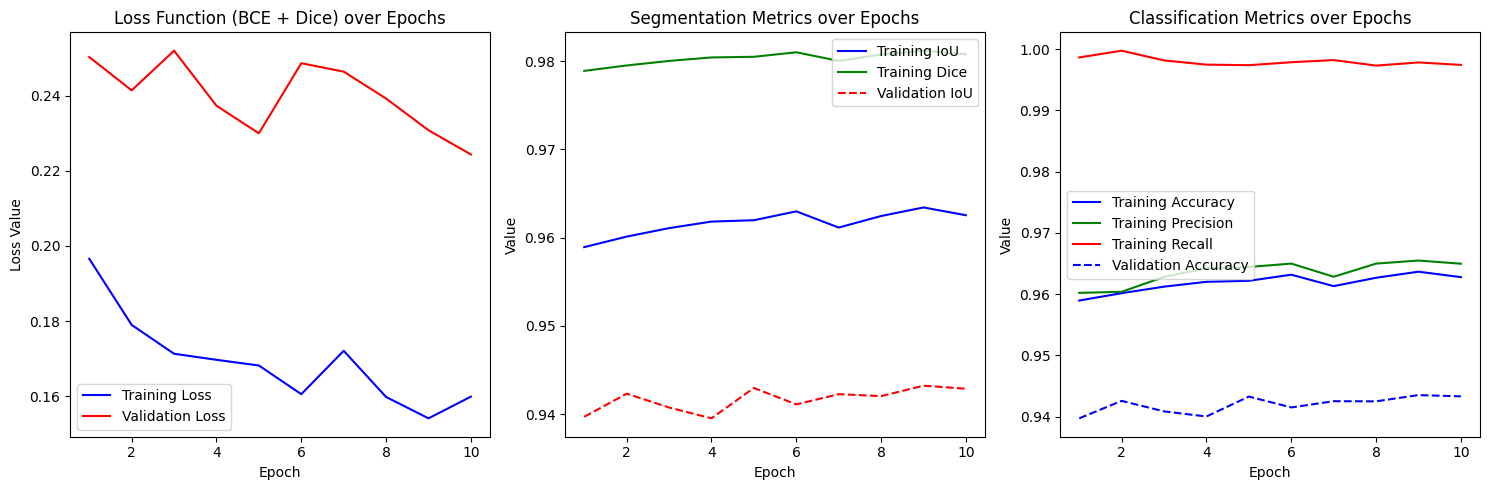


Generating prediction on a sample test image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


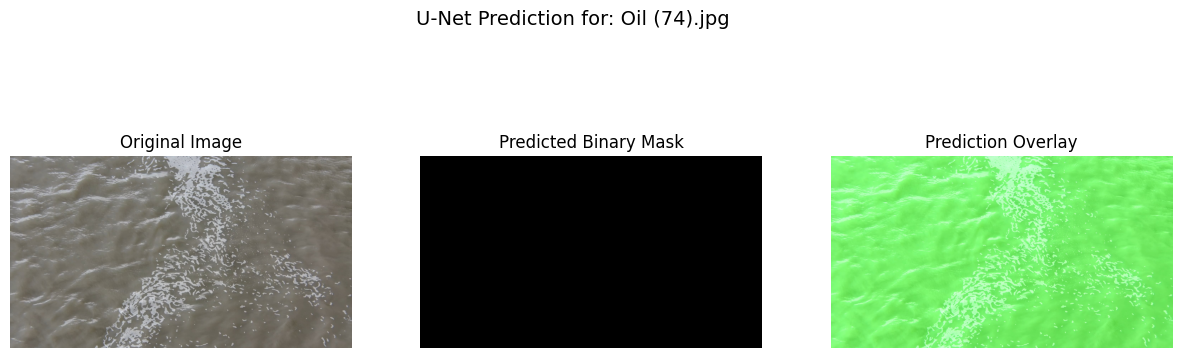


--- Model Execution Complete ---


In [ ]:
import os
import zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import albumentations as A

# Ensure albumentations is installed
try:
    import albumentations as A
except ImportError:
    print("Installing albumentations...")
    !pip install albumentations > /dev/null
    import albumentations as A
    print("Albumentations installed.")

# --- 1. SETUP: MOUNT DRIVE AND UNZIP DATASET ---

zip_file_path = '/content/drive/MyDrive/Oil_Spill_Dataset.zip'
extract_path = './'

# Mount Google Drive
from google.colab import drive
print("Attempting to mount Google Drive...")
drive.mount('/content/drive', force_remount=True)

if os.path.exists(zip_file_path):
    print(f"\nUnzipping {zip_file_path}...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Unzipping complete. Data is ready in the current directory.")
    except Exception as e:
        print(f"An error occurred during unzipping: {e}")
        exit()
else:
    print(f"\nFATAL ERROR: File not found: {zip_file_path}. Please check your file path.")
    exit()

# --- 2. CONFIGURATION & DATA SPLIT ---

IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 3
BATCH_SIZE = 8
TOTAL_EPOCHS = 10 # Set to 10 for better demonstration, increase for final run
VALIDATION_SPLIT = 0.2
LEARNING_RATE = 1e-4

DATASET_ROOT_DIR = './'
TRAIN_IMAGE_DIR = os.path.join(DATASET_ROOT_DIR, 'train', 'images')
TRAIN_MASK_DIR = os.path.join(DATASET_ROOT_DIR, 'train', 'masks')
TEST_IMAGE_DIR = os.path.join(DATASET_ROOT_DIR, 'test', 'images')

all_image_ids = sorted(os.listdir(TRAIN_IMAGE_DIR))

if not all_image_ids:
    print(f"FATAL ERROR: No images found in {TRAIN_IMAGE_DIR}. Check your folder structure.")
    exit()

# Split the data into training and validation sets
train_ids, val_ids = train_test_split(
    all_image_ids,
    test_size=VALIDATION_SPLIT,
    random_state=42
)

print(f"Total Images: {len(all_image_ids)}")
print(f"Training Images: {len(train_ids)}")
print(f"Validation Images: {len(val_ids)}")


# --- 3. LOSS FUNCTIONS AND METRICS (Custom Implementations) ---

def dice_coeff(y_true, y_pred, smooth=1e-7):
    """Dice Coefficient (F1 Score) - Metric"""
    y_pred = K.cast(y_pred > 0.5, K.floatx())
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """Dice Loss - Loss Function"""
    return 1.0 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    """Combined Loss: Binary Cross-Entropy + Dice Loss"""
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    # A common way to balance them is a simple sum
    return bce + dice

def iou_metric(y_true, y_pred, smooth=1e-7):
    """IoU (Intersection over Union) - Metric"""
    y_pred = K.cast(y_pred > 0.5, K.floatx())
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

# Define a set of metrics for comprehensive evaluation
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    iou_metric,
    dice_coeff
]

# --- 4. DATA AUGMENTATION PIPELINE ---

def get_training_augmentation():
    """Defines the real-time augmentation pipeline for training data."""
    return A.Compose([
        A.Resize(IMG_HEIGHT, IMG_WIDTH), # Resize first
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=20, p=0.7, border_mode=cv2.BORDER_REFLECT_101),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussNoise(p=0.2),
        A.OneOf([
            A.Blur(blur_limit=3, p=0.5),
            A.MedianBlur(blur_limit=3, p=0.5),
        ], p=0.5),
    ])

def get_validation_augmentation():
    """Defines the minimal augmentation (just resizing) for validation data."""
    return A.Compose([
        A.Resize(IMG_HEIGHT, IMG_WIDTH),
    ])

# --- 5. CUSTOM DATA GENERATOR with AUGMENTATION ---

class SegmentationDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_ids, image_dir, mask_dir, batch_size=BATCH_SIZE, augmentation=None, shuffle=True):
        self.image_ids = image_ids
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size
        self.augmentation = augmentation
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.image_ids) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        list_ids_temp = [self.image_ids[k] for k in indexes]
        return self.__data_generation(list_ids_temp)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.image_ids))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, list_ids_temp):
        X = np.empty((self.batch_size, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
        y = np.empty((self.batch_size, IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.float32)

        for i, name in enumerate(list_ids_temp):
            # Load Image
            img_path = os.path.join(self.image_dir, name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Load Mask
            mask_name = name.replace('.jpg', '.png')
            mask_path = os.path.join(self.mask_dir, mask_name)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = np.expand_dims(mask, axis=-1)

            # Apply Augmentation (on both image and mask)
            if self.augmentation:
                sample = self.augmentation(image=img, mask=mask)
                img_aug = sample['image']
                mask_aug = sample['mask']
            else:
                # Still need to resize if no augmentation is applied
                img_aug = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
                mask_aug = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
                mask_aug = np.expand_dims(mask_aug, axis=-1)

            # Normalize
            X[i,] = img_aug / 255.0
            y[i,] = (mask_aug > 0).astype(np.float32) # Ensure mask is binary (0 or 1)

        return X, y

# Instantiate Data Generators
train_generator = SegmentationDataGenerator(
    train_ids, TRAIN_IMAGE_DIR, TRAIN_MASK_DIR,
    augmentation=get_training_augmentation(), shuffle=True
)
validation_generator = SegmentationDataGenerator(
    val_ids, TRAIN_IMAGE_DIR, TRAIN_MASK_DIR,
    augmentation=get_validation_augmentation(), shuffle=False
)
print("Data Generators (Training with Augmentation, Validation without) initialized.")


# --- 6. U-NET MODEL DEFINITION (Same robust structure) ---

def unet_model(input_size=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    inputs = Input(input_size)
    # ENCODER
    conv1 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(inputs)
    conv1 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv4)
    drop4 = Dropout(0.5)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)
    # BOTTLENECK
    conv5 = Conv2D(1024, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool4)
    conv5 = Conv2D(1024, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv5)
    drop5 = Dropout(0.5)(conv5)
    # DECODER
    up6 = Conv2D(512, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(drop5))
    merge6 = concatenate([drop4, up6], axis=3)
    conv6 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge6)
    conv6 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv6)
    up7 = Conv2D(256, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(conv6))
    merge7 = concatenate([conv3, up7], axis=3)
    conv7 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge7)
    conv7 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv7)
    up8 = Conv2D(128, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(conv7))
    merge8 = concatenate([conv2, up8], axis=3)
    conv8 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge8)
    conv8 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv8)
    up9 = Conv2D(64, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(conv8))
    merge9 = concatenate([conv1, up9], axis=3)
    conv9 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge9)
    conv9 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv9)
    conv10 = Conv2D(1, 1, activation='sigmoid')(conv9)
    model = Model(inputs=inputs, outputs=conv10, name='U-Net')
    return model

# Initialize and Compile the Model
model = unet_model()

# Compile using the combined BCE + Dice Loss and the full set of metrics
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=bce_dice_loss, # Using the combined loss function
    metrics=METRICS
)

print("\nU-Net Model compiled with combined BCE+Dice Loss and full metrics.")


# --- 7. CALLBACKS (for Fine-Tuning) ---

callbacks = [
    # Fine-tune: Stop training if validation IoU doesn't improve for 10 epochs
    EarlyStopping(patience=10, verbose=1, monitor='val_iou_metric', mode='max', restore_best_weights=True),
    # Fine-tune: Reduce LR when validation IoU plateaus
    ReduceLROnPlateau(factor=0.2, patience=5, verbose=1, monitor='val_iou_metric', mode='max', min_lr=1e-7)
]


# --- 8. MODEL TRAINING WITH VALIDATION ---

print(f"\nStarting training for {TOTAL_EPOCHS} epochs with Validation and Augmentation...")

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=TOTAL_EPOCHS,
    validation_data=validation_generator, # Crucial for Hyperparameter Fine-Tuning
    validation_steps=len(validation_generator),
    callbacks=callbacks
)

print("\nTraining complete.")

# --- 9. EVALUATION PLOTTING (Loss and IoU) ---

print("\nGenerating performance plots...")
epochs = range(1, len(history.history['loss']) + 1)

# Plot Loss
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(epochs, history.history['loss'], 'b', label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(epochs, history.history['val_loss'], 'r', label='Validation Loss')
plt.title('Loss Function (BCE + Dice) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()

# Plot IoU/Dice Coefficient
plt.subplot(1, 3, 2)
plt.plot(epochs, history.history['iou_metric'], 'b', label='Training IoU')
plt.plot(epochs, history.history['dice_coeff'], 'g', label='Training Dice')
if 'val_iou_metric' in history.history:
    plt.plot(epochs, history.history['val_iou_metric'], 'r--', label='Validation IoU')
plt.title('Segmentation Metrics over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

# Plot Accuracy/Precision/Recall
plt.subplot(1, 3, 3)
plt.plot(epochs, history.history['accuracy'], 'b', label='Training Accuracy')
plt.plot(epochs, history.history['precision'], 'g', label='Training Precision')
plt.plot(epochs, history.history['recall'], 'r', label='Training Recall')
if 'val_accuracy' in history.history:
    plt.plot(epochs, history.history['val_accuracy'], 'b--', label='Validation Accuracy')
plt.title('Classification Metrics over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

# --- 10. VISUALIZATION AND PREDICTION (Test Sample) ---

print("\nGenerating prediction on a sample test image...")

test_image_ids = sorted(os.listdir(TEST_IMAGE_DIR))

if not test_image_ids:
    print(f"No test images found in {TEST_IMAGE_DIR}. Cannot visualize prediction.")
else:
    sample_image_id = test_image_ids[np.random.randint(0, len(test_image_ids))]
    sample_img_path = os.path.join(TEST_IMAGE_DIR, sample_image_id)

    sample_img = cv2.imread(sample_img_path)
    sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
    original_size = sample_img.shape[:2]

    input_img = cv2.resize(sample_img, (IMG_WIDTH, IMG_HEIGHT))
    input_img = input_img / 255.0
    input_img_batch = np.expand_dims(input_img, axis=0)

    prediction = model.predict(input_img_batch)[0]

    prediction_resized = cv2.resize(prediction, (original_size[1], original_size[0]), interpolation=cv2.INTER_NEAREST)
    binary_mask = (prediction_resized > 0.5).astype(np.uint8)

    color_mask = np.zeros_like(sample_img)
    color_mask[binary_mask == 1] = [0, 255, 0]
    overlay_img = cv2.addWeighted(sample_img, 1.0, color_mask, 0.5, 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(sample_img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(binary_mask, cmap='gray')
    axes[1].set_title('Predicted Binary Mask')
    axes[1].axis('off')

    axes[2].imshow(overlay_img)
    axes[2].set_title('Prediction Overlay')
    axes[2].axis('off')

    plt.suptitle(f"U-Net Prediction for: {sample_image_id}", fontsize=14)
    plt.show()

print("\n--- Model Execution Complete ---")

Attempting to mount Google Drive...
Mounted at /content/drive

Unzipping /content/drive/MyDrive/Oil_Spill_Dataset.zip...
Unzipping complete. Data is ready in the current directory.

No pre-trained model found at unet_oil_spill_segmentation.h5. Starting quick training for 5 epochs...
Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 67s 522ms/step - dice_coeff: 0.9786 - iou_metric: 0.9584 - loss: 0.1927
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 73s 513ms/step - dice_coeff: 0.9783 - iou_metric: 0.9579 - loss: 0.1681
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 83s 527ms/step - dice_coeff: 0.9770 - iou_metric: 0.9557 - loss: 0.1836
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 53s 521ms/step - dice_coeff: 0.9777 - iou_metric: 0.9568 - loss: 0.1698
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 54s 532ms/step - dice_coeff: 0.9780 - iou_metric: 0.9574 - loss: 0.1648


Quick training complete. Model saved to unet_oil_spill_segmentation.h5

Generating side-by-side comparisons with overlays for reporting...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


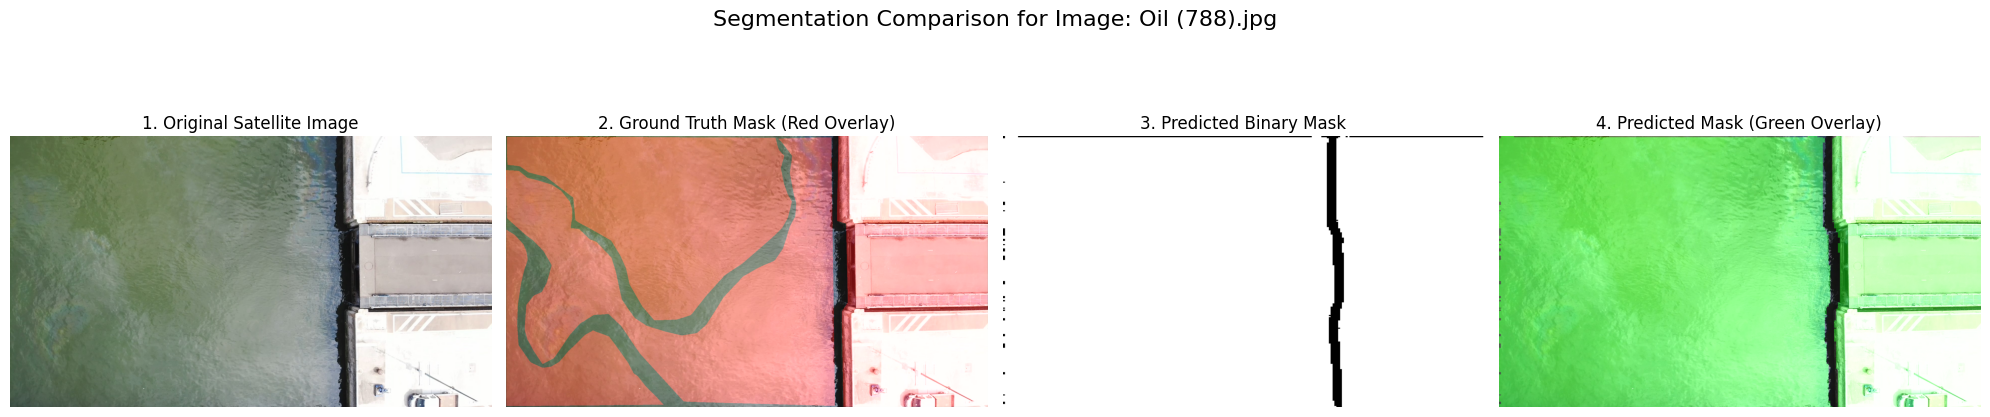

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


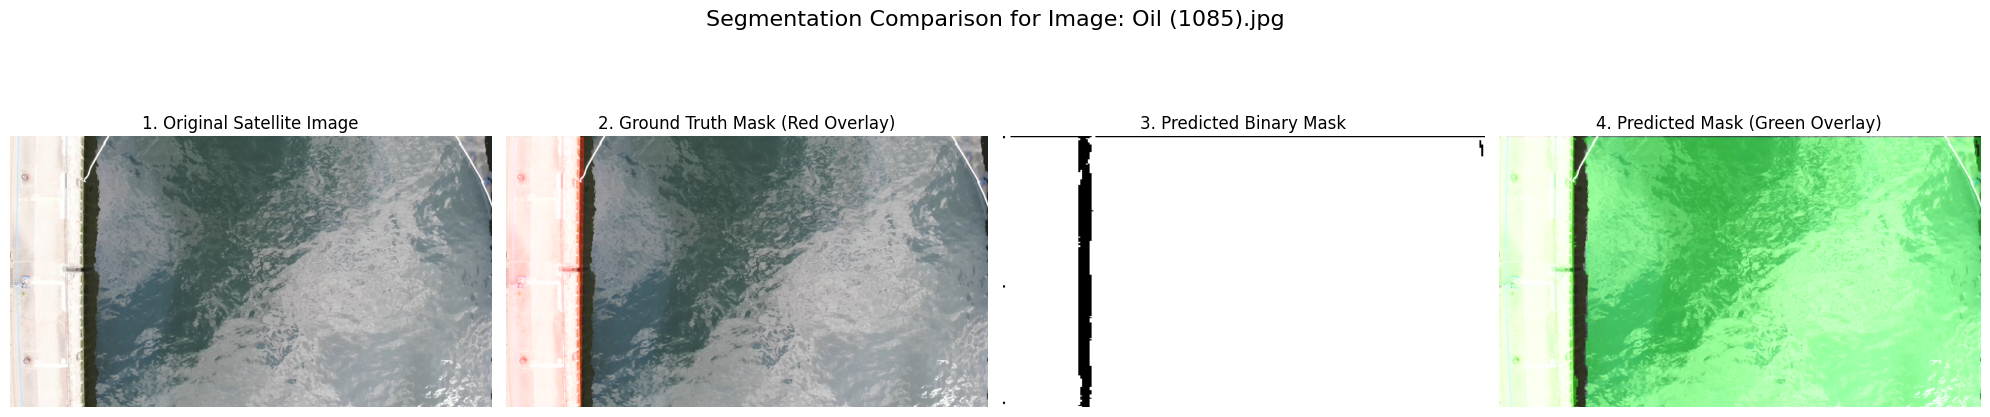

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


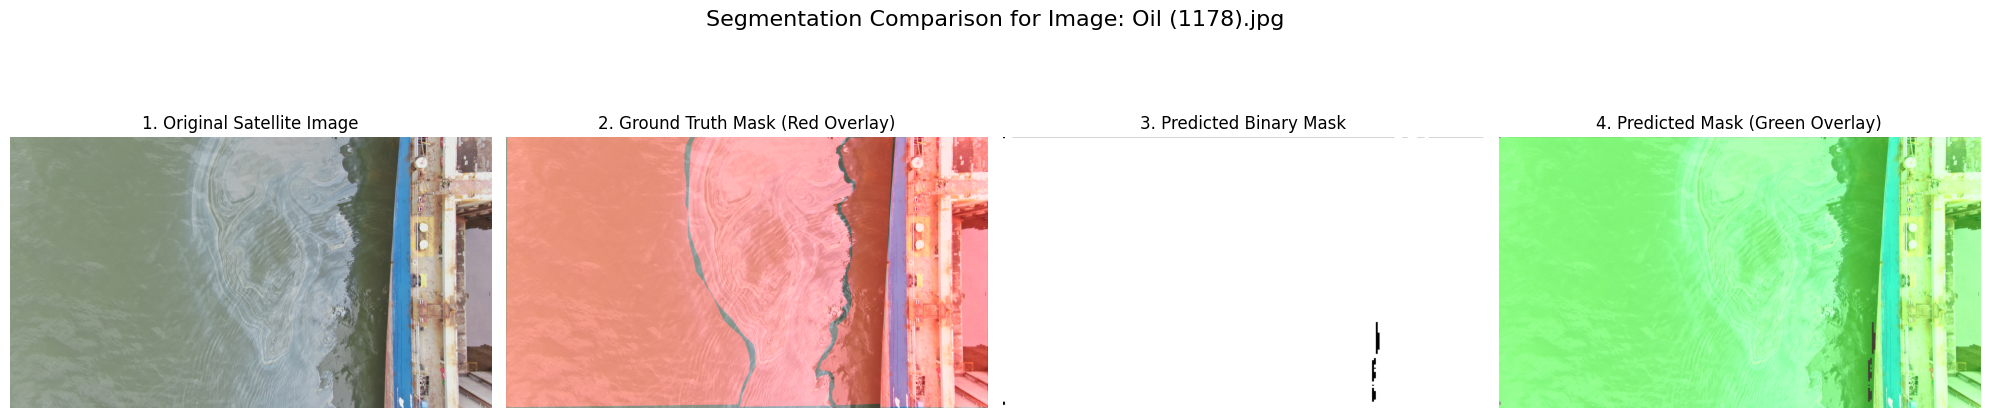


--- Visual Summary Generation Complete ---


In [ ]:
import os
import zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split # Needed for data generator setup
import albumentations as A # Needed for data generator setup

# --- 1. SETUP: MOUNT DRIVE, UNZIP DATASET, AND BASIC CONFIGURATION ---

zip_file_path = '/content/drive/MyDrive/Oil_Spill_Dataset.zip'
extract_path = './'
MODEL_WEIGHTS_PATH = 'unet_oil_spill_segmentation.h5' # Path to save/load model weights

IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 3
BATCH_SIZE = 8
DEMO_EPOCHS = 5 # Reduced for demonstration, increase for actual training

DATASET_ROOT_DIR = './'
TRAIN_IMAGE_DIR = os.path.join(DATASET_ROOT_DIR, 'train', 'images')
TRAIN_MASK_DIR = os.path.join(DATASET_ROOT_DIR, 'train', 'masks')
TEST_IMAGE_DIR = os.path.join(DATASET_ROOT_DIR, 'test', 'images')
TEST_MASK_DIR = os.path.join(DATASET_ROOT_DIR, 'test', 'masks') # Assuming test masks are available for ground truth

# Mount Google Drive
from google.colab import drive
print("Attempting to mount Google Drive...")
drive.mount('/content/drive', force_remount=True)

if os.path.exists(zip_file_path):
    print(f"\nUnzipping {zip_file_path}...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Unzipping complete. Data is ready in the current directory.")
    except Exception as e:
        print(f"An error occurred during unzipping: {e}")
        # Optionally delete potentially incomplete extraction and retry
        # shutil.rmtree(extract_path, ignore_errors=True)
        exit()
else:
    print(f"\nFATAL ERROR: File not found: {zip_file_path}. Please check your file path.")
    exit()

# --- 2. U-NET MODEL DEFINITION (Copied from previous steps for completeness) ---

def unet_model(input_size=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    inputs = Input(input_size)
    # ENCODER
    conv1 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(inputs)
    conv1 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv4)
    drop4 = Dropout(0.5)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)
    # BOTTLENECK
    conv5 = Conv2D(1024, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool4)
    conv5 = Conv2D(1024, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv5)
    drop5 = Dropout(0.5)(conv5)
    # DECODER
    up6 = Conv2D(512, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(drop5))
    merge6 = concatenate([drop4, up6], axis=3)
    conv6 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge6)
    conv6 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv6)
    up7 = Conv2D(256, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(conv6))
    merge7 = concatenate([conv3, up7], axis=3)
    conv7 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge7)
    conv7 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv7)
    up8 = Conv2D(128, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(conv7))
    merge8 = concatenate([conv2, up8], axis=3)
    conv8 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge8)
    conv8 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv8)
    up9 = Conv2D(64, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(conv8))
    merge9 = concatenate([conv1, up9], axis=3)
    conv9 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge9)
    conv9 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv9)
    conv10 = Conv2D(1, 1, activation='sigmoid')(conv9)
    model = Model(inputs=inputs, outputs=conv10, name='U-Net')
    return model

# --- 3. CUSTOM METRICS AND LOSS FUNCTIONS (for model compilation if training) ---

def dice_coeff(y_true, y_pred, smooth=1e-7):
    y_pred = K.cast(y_pred > 0.5, K.floatx())
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

def iou_metric(y_true, y_pred, smooth=1e-7):
    y_pred = K.cast(y_pred > 0.5, K.floatx())
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

# --- 4. DATA GENERATOR (Only for quick training if no model is loaded) ---

class SegmentationDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_ids, image_dir, mask_dir, batch_size=BATCH_SIZE, augmentation=None, shuffle=True):
        self.image_ids = image_ids
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size
        self.augmentation = augmentation
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.image_ids) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        list_ids_temp = [self.image_ids[k] for k in indexes]
        return self.__data_generation(list_ids_temp)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.image_ids))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, list_ids_temp):
        X = np.empty((self.batch_size, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
        y = np.empty((self.batch_size, IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.float32)

        for i, name in enumerate(list_ids_temp):
            img_path = os.path.join(self.image_dir, name)
            mask_name = name.replace('.jpg', '.png')
            mask_path = os.path.join(self.mask_dir, mask_name)

            img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            mask = np.expand_dims(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE), axis=-1)

            # Minimal augmentation or just resizing for this quick load
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
            mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
            mask = np.expand_dims(mask, axis=-1) # Ensure mask is (H,W,1)

            X[i,] = img / 255.0
            y[i,] = (mask > 0).astype(np.float32)
        return X, y

# --- 5. MODEL LOADING OR QUICK TRAINING ---

model = unet_model()

# Custom objects needed for loading model if custom loss/metrics were used
custom_objects = {'dice_coeff': dice_coeff, 'dice_loss': dice_loss, 'bce_dice_loss': bce_dice_loss, 'iou_metric': iou_metric}

if os.path.exists(MODEL_WEIGHTS_PATH):
    print(f"\nLoading pre-trained model from {MODEL_WEIGHTS_PATH}...")
    try:
        model = tf.keras.models.load_model(MODEL_WEIGHTS_PATH, custom_objects=custom_objects)
        print("Model loaded successfully.")
    except Exception as e:
        print(f"Error loading model: {e}. Will attempt to train a new model.")
        # Recompile if loading failed or for new training
        model.compile(optimizer=Adam(learning_rate=1e-4), loss=bce_dice_loss, metrics=[iou_metric, dice_coeff])
        all_train_ids = sorted(os.listdir(TRAIN_IMAGE_DIR))
        train_generator = SegmentationDataGenerator(all_train_ids, TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, shuffle=True)
        print(f"Starting quick training for {DEMO_EPOCHS} epochs...")
        model.fit(train_generator, steps_per_epoch=len(train_generator), epochs=DEMO_EPOCHS)
        model.save(MODEL_WEIGHTS_PATH)
        print(f"Quick training complete. Model saved to {MODEL_WEIGHTS_PATH}")
else:
    print(f"\nNo pre-trained model found at {MODEL_WEIGHTS_PATH}. Starting quick training for {DEMO_EPOCHS} epochs...")
    model.compile(optimizer=Adam(learning_rate=1e-4), loss=bce_dice_loss, metrics=[iou_metric, dice_coeff])
    all_train_ids = sorted(os.listdir(TRAIN_IMAGE_DIR))
    train_generator = SegmentationDataGenerator(all_train_ids, TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, shuffle=True)
    model.fit(train_generator, steps_per_epoch=len(train_generator), epochs=DEMO_EPOCHS)
    model.save(MODEL_WEIGHTS_PATH)
    print(f"Quick training complete. Model saved to {MODEL_WEIGHTS_PATH}")

# --- 6. VISUALIZATION: SIDE-BY-SIDE COMPARISONS AND OVERLAYS (CORRECTED) ---

print("\nGenerating side-by-side comparisons with overlays for reporting...")

# Get list of test image IDs
test_image_ids = sorted(os.listdir(TEST_IMAGE_DIR))
TEST_MASK_DIR = os.path.join(DATASET_ROOT_DIR, 'test', 'masks') # Ensure this path is defined

if not test_image_ids:
    print(f"No test images found in {TEST_IMAGE_DIR}. Cannot generate comparisons.")
else:
    # Select a few random images for comparison (e.g., 3 images)
    num_comparisons = min(3, len(test_image_ids))
    sample_image_ids = np.random.choice(test_image_ids, num_comparisons, replace=False)

    for i, image_id in enumerate(sample_image_ids):
        # Construct paths
        original_img_path = os.path.join(TEST_IMAGE_DIR, image_id)
        ground_truth_mask_path = os.path.join(TEST_MASK_DIR, image_id.replace('.jpg', '.png'))

        # Load original image
        original_img = cv2.imread(original_img_path)
        original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        original_size = original_img_rgb.shape[:2]

        # Load ground truth mask
        ground_truth_mask = cv2.imread(ground_truth_mask_path, cv2.IMREAD_GRAYSCALE)
        ground_truth_mask_binary = (ground_truth_mask > 0).astype(np.uint8)

        # Prepare image for prediction
        input_img_for_pred = cv2.resize(original_img_rgb, (IMG_WIDTH, IMG_HEIGHT))
        input_img_for_pred = input_img_for_pred / 255.0
        input_img_batch = np.expand_dims(input_img_for_pred, axis=0)

        # Get model prediction (Output shape: (1, 256, 256, 1))
        predicted_mask_prob = model.predict(input_img_batch)[0]

        # --- FIX STARTS HERE ---
        # 1. Collapse the channel dimension (from (256, 256, 1) to (256, 256))
        predicted_mask_prob_2d = predicted_mask_prob[:, :, 0]

        # 2. Resize the 2D array back to original size
        predicted_mask_resized = cv2.resize(
            predicted_mask_prob_2d,
            (original_size[1], original_size[0]),
            interpolation=cv2.INTER_NEAREST
        )

        # 3. Convert probability map to binary mask (0 or 1)
        predicted_mask_binary = (predicted_mask_resized > 0.5).astype(np.uint8)
        # --- FIX ENDS HERE ---

        # --- Create Visualizations ---

        # 1. Ground Truth Overlay
        gt_color_mask = np.zeros_like(original_img_rgb)
        gt_color_mask[ground_truth_mask_binary == 1] = [255, 0, 0] # Red for Ground Truth
        gt_overlay_img = cv2.addWeighted(original_img_rgb, 1.0, gt_color_mask, 0.4, 0)

        # 2. Prediction Overlay
        pred_color_mask = np.zeros_like(original_img_rgb)
        pred_color_mask[predicted_mask_binary == 1] = [0, 255, 0] # Green for Prediction
        pred_overlay_img = cv2.addWeighted(original_img_rgb, 1.0, pred_color_mask, 0.4, 0)


        # --- PLOTTING FOR REPORT/DASHBOARD ---

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(f"Segmentation Comparison for Image: {image_id}", fontsize=16)

        axes[0].imshow(original_img_rgb)
        axes[0].set_title('1. Original Satellite Image')
        axes[0].axis('off')

        axes[1].imshow(gt_overlay_img)
        axes[1].set_title('2. Ground Truth Mask (Red Overlay)')
        axes[1].axis('off')

        axes[2].imshow(predicted_mask_binary, cmap='gray')
        axes[2].set_title('3. Predicted Binary Mask')
        axes[2].axis('off')

        axes[3].imshow(pred_overlay_img)
        axes[3].set_title('4. Predicted Mask (Green Overlay)')
        axes[3].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

print("\n--- Visual Summary Generation Complete ---")